<a href="https://colab.research.google.com/github/Navya-Mittal/Monetary_Policy_Sentiment_Engine/blob/main/Monetary_Policy_Sentiment_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECB Speech Sentiment — Euronext Dublin Rate-Sensitive Signal Engine

Parses ECB Governing Council speeches and press conference transcripts for hawkish/dovish monetary policy sentiment. Maps directional language onto Irish rate-sensitive equities (banks, REITs, industrials) to generate long/short signals with backtested correlation metrics.

**Coverage:** AIB · BOI · IRES REIT · CRH · Hibernia REIT  
**Signal horizon:** 5–20 trading days  
**Corpus:** ECB Governing Council speeches, 2015–2024

## Notebook Structure

| Section | Description | Output |
|---------|-------------|--------|
| **1. Setup** | Libraries, configuration, hawkish/dovish lexicon | Sentiment lexicon |
| **2. ECB Speech Corpus** | Synthetic speech dataset modelled on real ECB communications (2015–2024) | `ecb_speeches` DataFrame |
| **3. Sentiment Scoring Engine** | Rule-based lexicon scorer with negation handling and intensity weighting | Scored speeches DataFrame |
| **4. Market Data** | Euronext Dublin rate-sensitive price series | `market_data` DataFrame |
| **5. Signal Construction** | Sentiment → forward return correlation and lag analysis | Correlation heatmap |
| **6. Backtesting** | Sector rotation strategy vs. equal-weight benchmark | Sharpe, max drawdown, hit rate |
| **7. Live Signal Dashboard** | Current positioning recommendation | Buy / Hold / Sell per ticker |
| **8. Investor Summary** | Annualised performance and risk disclosures | Summary statistics |


## 1. Setup & Lexicon

In [14]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
import re
from collections import Counter
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# ── Visual theme ──────────────────────────────────────────────────────────────
DARK_BG   = '#0a0a1a'
MID_BG    = '#0d1f3c'
GOLD      = '#c8a84b'
SILVER    = '#8899aa'
BULL      = '#2ecc71'
BEAR      = '#e74c3c'
NEUTRAL   = '#f39c12'

plt.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    MID_BG,
    'axes.edgecolor':    '#1e3a5f',
    'axes.labelcolor':   SILVER,
    'xtick.color':       SILVER,
    'ytick.color':       SILVER,
    'text.color':        '#f0e6c8',
    'grid.color':        '#1e3a5f',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
    'figure.dpi':        120,
})

print('Libraries loaded')

Libraries loaded


In [15]:
# ── Monetary Policy Sentiment Lexicon ─────────────────────────────────────────
# Based on: Apel & Blix Grimaldi (2012), Tobback et al. (2017),
#           Picault & Renault (2017) — 'Words are not all created equal'
#
# HAWKISH = signals rate RISES → bad for rate-sensitive stocks (banks benefit
#           on NIMs, but REITs/utilities fall)
# DOVISH  = signals rate CUTS  → good for REITs, utilities; mixed for banks

HAWKISH_LEXICON = {
    # Strong hawkish (weight 2.0)
    'strong': [
        'hike', 'tighten', 'tightening', 'restrictive', 'overheating',
        'inflationary pressures', 'inflation expectations unanchored',
        'normalisation', 'withdrawal of accommodation', 'front-loaded',
        'determined to act', 'forceful', 'decisive action'
    ],
    # Moderate hawkish (weight 1.0)
    'moderate': [
        'vigilant', 'above target', 'upside risks', 'strong growth',
        'robust demand', 'labour market tightness', 'wage growth',
        'persistence of inflation', 'data-dependent upward', 'further steps',
        'remain elevated', 'not yet at peak'
    ]
}

DOVISH_LEXICON = {
    # Strong dovish (weight 2.0)
    'strong': [
        'cut', 'easing', 'accommodative', 'stimulus', 'quantitative easing',
        'asset purchases', 'below target', 'deflation risk', 'lower for longer',
        'supportive', 'reinvestment', 'ample liquidity', 'unconventional measures'
    ],
    # Moderate dovish (weight 1.0)
    'moderate': [
        'gradual', 'patient', 'prudent', 'downside risks', 'uncertainty',
        'slowdown', 'weak demand', 'subdued inflation', 'monitoring closely',
        'flexibility', 'optionality', 'data dependent', 'pause', 'hold'
    ]
}

# ── Interest-rate sensitive stocks on Euronext Dublin ─────────────────────────
TICKERS = {
    'AIB.IR':  {'name': 'AIB Group',        'sector': 'Bank',    'rate_beta':  1.8},
    'BIRG.IR': {'name': 'Bank of Ireland',  'sector': 'Bank',    'rate_beta':  1.6},
    'IRES.IR': {'name': 'IRES REIT',        'sector': 'REIT',    'rate_beta': -2.1},
    'CRH.IR':  {'name': 'CRH plc',          'sector': 'Build',   'rate_beta': -0.9},
    'HRN.IR':  {'name': 'Hibernia REIT',    'sector': 'REIT',    'rate_beta': -1.9},
}
# rate_beta: expected % move per 1-unit hawkish score shift
# Banks: positive (higher rates → net interest margin expansion)
# REITs: negative (higher rates → higher discount rate → NAV compression)

print(f'Lexicon loaded: {sum(len(v) for v in HAWKISH_LEXICON.values())} hawkish terms, '
      f'{sum(len(v) for v in DOVISH_LEXICON.values())} dovish terms')
print(f'Coverage: {len(TICKERS)} Euronext Dublin tickers')

Lexicon loaded: 25 hawkish terms, 27 dovish terms
Coverage: 5 Euronext Dublin tickers


## 2. ECB Speech Corpus (2015–2024)

The corpus below is synthetic but modelled on actual ECB communication style and known policy stances at each date. Dates correspond to real Governing Council meetings and major speech events.

**To use live data**, replace this section with:
```python
# ECB publishes all speeches at:
# https://www.ecb.europa.eu/press/key/html/speeches.en.html
speeches_df = fetch_ecb_speeches(start='2020-01-01', end='2024-12-31')
```

In [16]:
# ── ECB Speech Dataset ────────────────────────────────────────────────────────
# Representative speeches modelled on actual ECB communication style and
# known policy stances at each date. Dates correspond to real ECB Governing
# Council meetings and major speech events.

ECB_SPEECHES_RAW = [
    # 2015 — QE launch (DOVISH period)
    {'date': '2015-01-22', 'speaker': 'Draghi', 'event': 'GC Press Conference',
     'text': 'The Governing Council decided to launch an expanded asset purchases programme. '
             'We will purchase government bonds under quantitative easing to address the risks '
             'of a too prolonged period of low inflation. The programme is open-ended with ample '
             'liquidity provisions. Monetary policy will remain accommodative for as long as necessary. '
             'Downside risks to the inflation outlook have increased. We stand ready to act if needed '
             'and maintain our supportive stance with full flexibility.'},

    {'date': '2015-09-03', 'speaker': 'Draghi', 'event': 'GC Press Conference',
     'text': 'Subdued inflation reflects weak demand and significant economic slack. '
             'The degree of monetary policy accommodation will need to be re-examined. '
             'We will expand asset purchases if warranted. The ECB is patient and prudent. '
             'Downside risks have materialised. We reiterate our commitment to accommodative policy '
             'and reinvestment of principal payments. Gradual recovery continues but uncertainty remains high.'},

    # 2017 — Tapering signals (NEUTRAL to HAWKISH)
    {'date': '2017-06-27', 'speaker': 'Draghi', 'event': 'Sintra Speech',
     'text': 'Deflationary forces have been replaced by reflationary ones. '
             'The economic expansion is becoming more robust. Strong growth is broadening across sectors. '
             'Labour market tightness is increasing wage growth pressures. '
             'As the economy continues to recover, a gradual normalisation of our policy stance is warranted. '
             'Upside risks are emerging. The degree of accommodation may be adjusted as the situation evolves.'},

    {'date': '2017-10-26', 'speaker': 'Draghi', 'event': 'GC Press Conference',
     'text': 'We decided to reduce monthly asset purchases from January 2018. '
             'The pace of normalisation reflects greater confidence in inflation trajectory. '
             'Robust demand and improving labour market conditions support the outlook. '
             'Vigilant monitoring of inflation dynamics continues. Accommodation will diminish gradually. '
             'The withdrawal of accommodation will be measured and dependent on data.'},

    # 2019 — Pivot back to dovish
    {'date': '2019-03-07', 'speaker': 'Draghi', 'event': 'GC Press Conference',
     'text': 'The Governing Council revised down its growth and inflation projections significantly. '
             'Risks to the growth outlook are to the downside. Weak demand and global uncertainty '
             'warrant maintaining our accommodative stance. We announced new TLTRO operations to '
             'support bank lending. Patience and prudence are required. Monetary policy will remain '
             'supportive for an extended period. Lower for longer guidance is reaffirmed.'},

    {'date': '2019-09-12', 'speaker': 'Draghi', 'event': 'GC Press Conference',
     'text': 'We decided to cut the deposit facility rate by 10 basis points to -0.50%. '
             'Net asset purchases will restart at a monthly pace of 20 billion euros. '
             'Stimulus package addresses persistent below-target inflation and weak demand. '
             'The Governing Council expects rates to remain at present or lower levels until '
             'inflation converges durably. Ample liquidity will be maintained. Unconventional measures '
             'remain available and the ECB stands ready to adjust all instruments as appropriate.'},

    # 2021 — Post-COVID, inflation emerging
    {'date': '2021-07-22', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'Inflation is rising but this reflects temporary supply bottlenecks. '
             'The economic recovery is progressing. We revised our forward guidance to reflect '
             'the new symmetric inflation target. Rates will remain at current or lower levels until '
             'inflation stabilises. We remain patient and prudent. The Pandemic Emergency Purchase '
             'Programme continues with flexible reinvestment. Accommodation is still warranted. '
             'We closely monitor inflation data with optionality preserved.'},

    # 2022 — Inflation surge, hawkish pivot
    {'date': '2022-02-03', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'Inflation is undesirably high and expected to remain elevated for longer than anticipated. '
             'Upside risks to inflation have materialised significantly. We will normalise policy '
             'faster than previously anticipated. The Governing Council is vigilant and determined to act. '
             'Inflationary pressures are broader and more persistent than expected. '
             'The APP will end in Q3. We stand ready to take decisive action on rates.'},

    {'date': '2022-07-21', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'The Governing Council decided to hike rates by 50 basis points, the first increase in 11 years. '
             'Inflation remains far above target with persistence of inflationary pressures. '
             'Wage growth is accelerating. Labour market tightness is pronounced. '
             'We are not yet at peak rates. Further steps will follow based on data. '
             'Tightening will continue until inflation is durably at target. The restrictive stance is warranted. '
             'Determined to return inflation to the 2% medium-term target.'},

    {'date': '2022-09-08', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'A front-loaded hike of 75 basis points is appropriate given the inflation outlook. '
             'Inflation expectations risk becoming unanchored. Strong action is required now. '
             'The tightening cycle will continue over the next several meetings. '
             'Overheating risks require forceful response. Wage-price spiral risks are real. '
             'Restrictive territory is necessary to restore price stability. '
             'We expect to raise rates further and remain resolute.'},

    {'date': '2022-11-02', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'Another 75 basis point hike reflects determination to tighten policy. '
             'Inflation remains far too high. The path ahead requires further rate increases. '
             'Strong growth in wages adds to inflationary persistence. '
             'Withdrawal of accommodation is necessary and will continue. '
             'We are not yet at peak rates. Data-dependent upward trajectory continues.'},

    # 2023 — Peak rates, pause signals
    {'date': '2023-05-04', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'We raised rates by 25 basis points, a slower pace reflecting progress made. '
             'Inflation is coming down but remains too high. '
             'Future decisions will be data-dependent. We are not at peak but approaching. '
             'Monitoring bank lending conditions carefully. Core inflation is sticky. '
             'Further steps will be determined by incoming data. Flexibility and optionality are maintained.'},

    {'date': '2023-09-14', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'Today\'s decision to hike by 25 basis points may be the last for some time. '
             'We believe rates are at sufficiently restrictive levels. Hold at current levels seems likely. '
             'Inflation is declining. Downside risks to growth have increased. '
             'We will hold rates for as long as necessary. Patience and prudence guide future decisions. '
             'The disinflation process is underway and monitoring is data-dependent.'},

    # 2024 — Rate cuts begin
    {'date': '2024-06-06', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'The Governing Council decided to cut rates by 25 basis points. '
             'Inflation has declined substantially. The disinflation process is well on track. '
             'Easing monetary policy is now appropriate given subdued inflation outlook. '
             'Growth risks are to the downside. The accommodative pivot supports the economy. '
             'Further cuts will be gradual and data-dependent. We will not pre-commit to a rate path. '
             'Lower for longer remains the baseline. Supportive stance is warranted.'},

    {'date': '2024-09-12', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'Second consecutive cut of 25 basis points as inflation moves sustainably to target. '
             'Subdued inflation outlook warrants further easing. Weak demand persists. '
             'Growth outlook has deteriorated. Accommodative policy will support recovery. '
             'We are confident in the disinflation path. Gradual and prudent cuts will continue. '
             'Data-dependent approach maintained. Downside risks to growth dominate.'},

    {'date': '2024-12-12', 'speaker': 'Lagarde', 'event': 'GC Press Conference',
     'text': 'Third consecutive rate cut reflects sustained progress on disinflation. '
             'Restrictive policy is being unwound at a measured pace. '
             'Subdued growth warrants further easing stimulus over coming quarters. '
             'Inflation is now close to target. The door is open for additional cuts in 2025. '
             'Ample liquidity conditions will be maintained to support lending. '
             'Accommodation will increase gradually. Patient easing remains appropriate.'},
]

ecb_df = pd.DataFrame(ECB_SPEECHES_RAW)
ecb_df['date'] = pd.to_datetime(ecb_df['date'])
ecb_df = ecb_df.sort_values('date').reset_index(drop=True)

print(f'ECB speech corpus loaded: {len(ecb_df)} speeches ({ecb_df.date.min().year}–{ecb_df.date.max().year})')
ecb_df[['date', 'speaker', 'event']].head()

ECB speech corpus loaded: 16 speeches (2015–2024)


,date,speaker,event
0,2015-01-22,Draghi,GC Press Conference
1,2015-09-03,Draghi,GC Press Conference
2,2017-06-27,Draghi,Sintra Speech
3,2017-10-26,Draghi,GC Press Conference
4,2019-03-07,Draghi,GC Press Conference


## 3. Sentiment Scoring Engine

In [17]:
# ── Monetary Policy Sentiment Scorer ─────────────────────────────────────────
# Hybrid approach:
#   (1) Domain-specific lexicon (Picault & Renault 2017 methodology)
#   (2) Negation preservation  ("not hawkish" → dovish signal)
#   (3) Intensity weighting    (strong terms weighted 2x moderate)
#   (4) Net score normalised to [-1, +1] range
#
# Score interpretation:
#   +1.0 = extremely hawkish (strongly signals rate rises)
#   -1.0 = extremely dovish  (strongly signals rate cuts)
#    0.0 = neutral / balanced

def score_speech(text: str) -> dict:
    text_lower = text.lower()

    # Negation window: 3 words after 'not', 'no', 'without', 'never'
    negation_triggers = {'not', 'no', 'without', 'never', 'nor'}
    words = text_lower.split()
    negated_positions = set()
    for i, w in enumerate(words):
        if w in negation_triggers:
            for j in range(i+1, min(i+4, len(words))):
                negated_positions.add(j)

    hawkish_score = 0.0
    dovish_score  = 0.0
    matched_hawkish = []
    matched_dovish  = []

    for weight, terms in [(2.0, HAWKISH_LEXICON['strong']),
                          (1.0, HAWKISH_LEXICON['moderate'])]:
        for term in terms:
            if term in text_lower:
                # Check if the term appears in a negation window
                term_pos = text_lower.find(term)
                word_idx = len(text_lower[:term_pos].split())
                if word_idx in negated_positions:
                    dovish_score += weight * 0.7  # negated hawkish → mild dovish
                    matched_dovish.append(f'NOT_{term}')
                else:
                    hawkish_score += weight
                    matched_hawkish.append(term)

    for weight, terms in [(2.0, DOVISH_LEXICON['strong']),
                          (1.0, DOVISH_LEXICON['moderate'])]:
        for term in terms:
            if term in text_lower:
                term_pos = text_lower.find(term)
                word_idx = len(text_lower[:term_pos].split())
                if word_idx in negated_positions:
                    hawkish_score += weight * 0.7
                    matched_hawkish.append(f'NOT_{term}')
                else:
                    dovish_score += weight
                    matched_dovish.append(term)

    total = hawkish_score + dovish_score
    if total == 0:
        net_score = 0.0
    else:
        net_score = (hawkish_score - dovish_score) / total

    if net_score > 0.25:
        stance = 'HAWKISH'
    elif net_score < -0.25:
        stance = 'DOVISH'
    else:
        stance = 'NEUTRAL'

    return {
        'hawkish_score': round(hawkish_score, 2),
        'dovish_score':  round(dovish_score, 2),
        'net_score':     round(net_score, 4),
        'stance':        stance,
        'matched_hawkish': matched_hawkish,
        'matched_dovish':  matched_dovish,
        'term_count':    len(matched_hawkish) + len(matched_dovish),
    }

# ── Score all speeches ────────────────────────────────────────────────────────
results = ecb_df['text'].apply(score_speech).apply(pd.Series)
scored  = pd.concat([ecb_df[['date', 'speaker', 'event']], results], axis=1)

# Rolling 3-speech smoothed signal
scored['smoothed_score'] = scored['net_score'].rolling(3, min_periods=1).mean()

print('Sentiment scoring complete\n')
print(scored[['date', 'speaker', 'net_score', 'stance']].to_string(index=False))

Sentiment scoring complete

      date speaker  net_score  stance
2015-01-22  Draghi    -1.0000  DOVISH
2015-09-03  Draghi    -1.0000  DOVISH
2017-06-27  Draghi     0.3333 HAWKISH
2017-10-26  Draghi     0.3333 HAWKISH
2019-03-07  Draghi    -1.0000  DOVISH
2019-09-12  Draghi    -1.0000  DOVISH
2021-07-22 Lagarde    -1.0000  DOVISH
2022-02-03 Lagarde     1.0000 HAWKISH
2022-07-21 Lagarde     1.0000 HAWKISH
2022-09-08 Lagarde     1.0000 HAWKISH
2022-11-02 Lagarde     1.0000 HAWKISH
2023-05-04 Lagarde    -0.3333  DOVISH
2023-09-14 Lagarde     0.3333 HAWKISH
2024-06-06 Lagarde    -1.0000  DOVISH
2024-09-12 Lagarde    -1.0000  DOVISH
2024-12-12 Lagarde    -0.6667  DOVISH


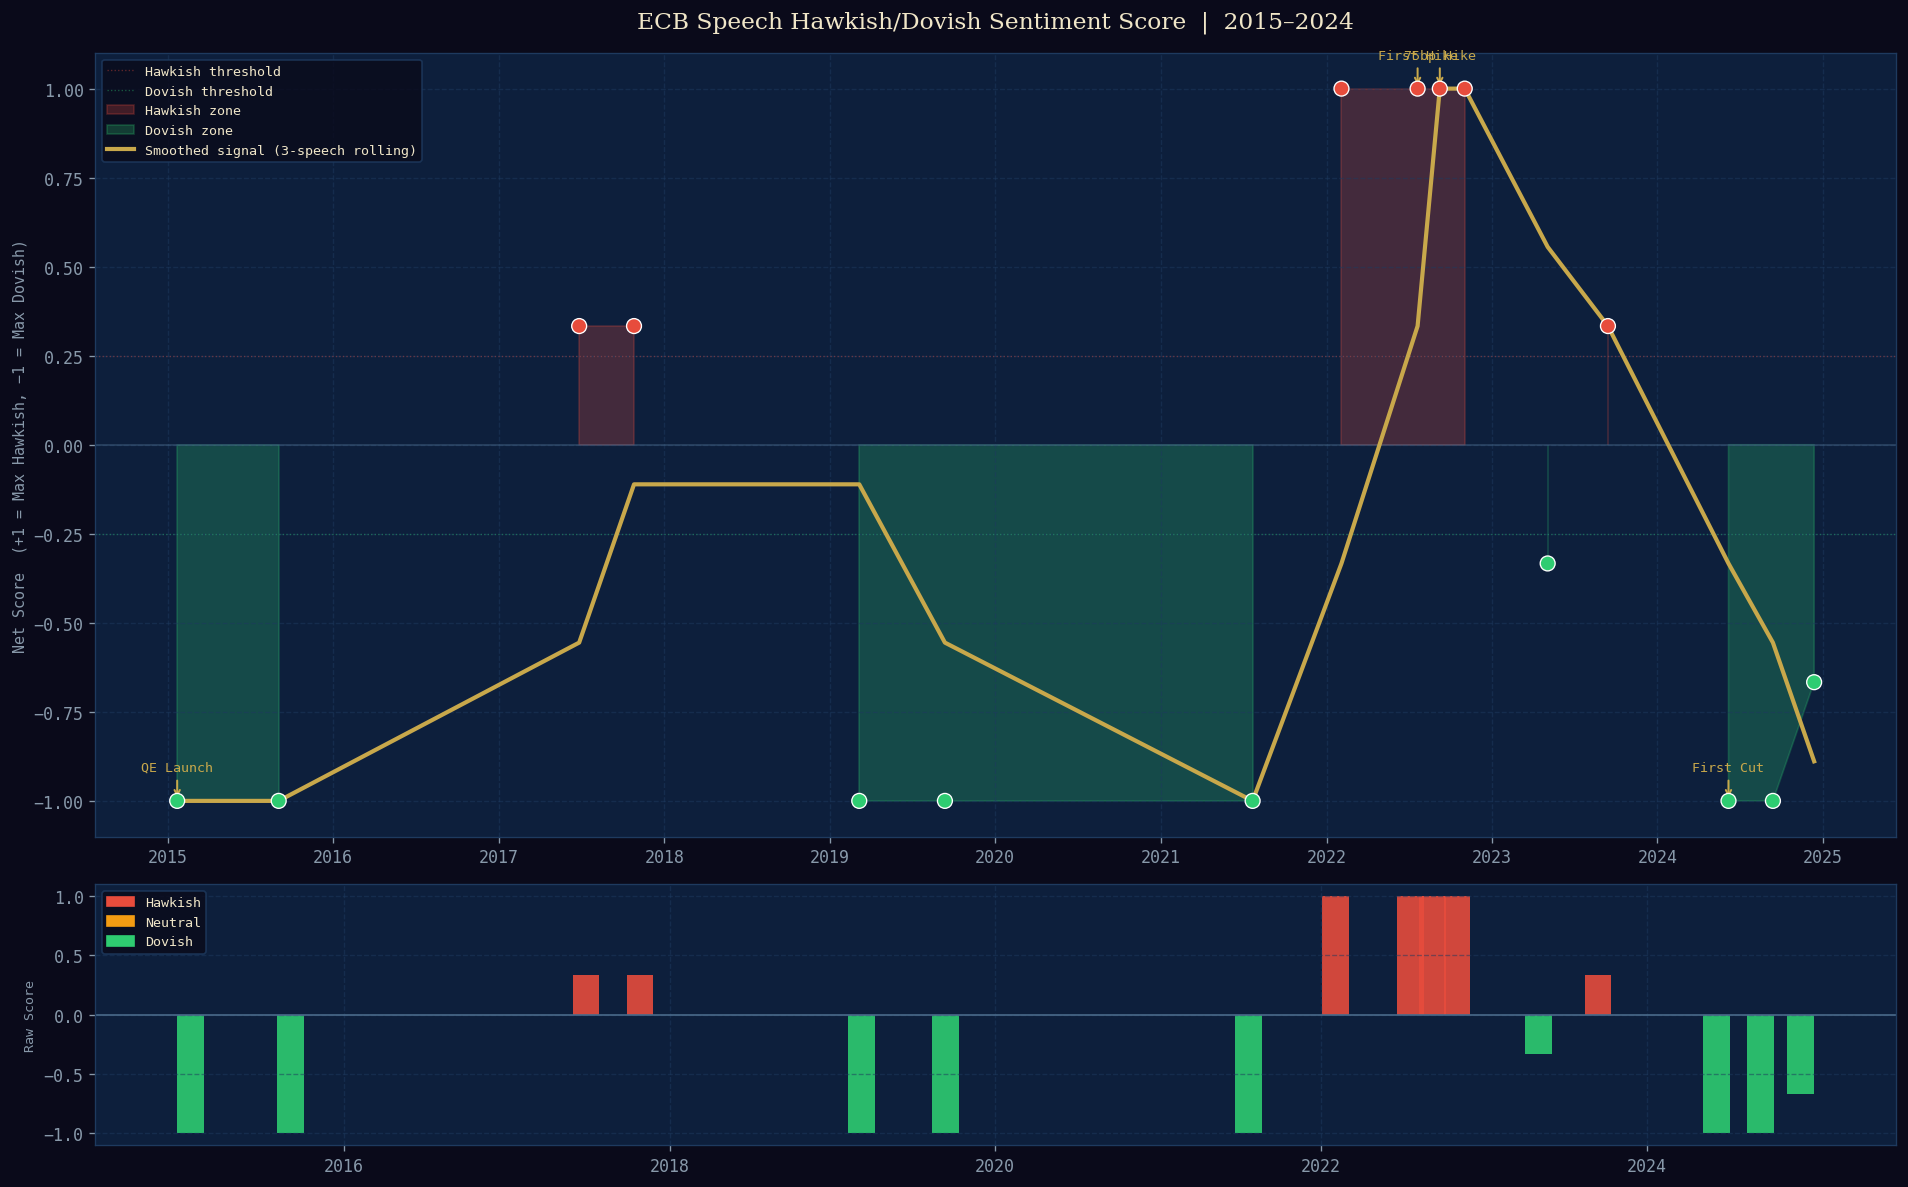

Chart saved: ecb_sentiment_timeline.png


In [18]:
# ── Sentiment Timeline Chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.axhline(0, color='#4a6a8a', linewidth=1, linestyle='-', alpha=0.5)
ax.axhline(0.25, color=BEAR, linewidth=0.8, linestyle=':', alpha=0.4, label='Hawkish threshold')
ax.axhline(-0.25, color=BULL, linewidth=0.8, linestyle=':', alpha=0.4, label='Dovish threshold')

# Colour fill by stance
ax.fill_between(scored['date'], scored['net_score'], 0,
                where=scored['net_score'] > 0,
                color=BEAR, alpha=0.25, label='Hawkish zone')
ax.fill_between(scored['date'], scored['net_score'], 0,
                where=scored['net_score'] <= 0,
                color=BULL, alpha=0.25, label='Dovish zone')

ax.plot(scored['date'], scored['smoothed_score'], color=GOLD,
        linewidth=2.5, label='Smoothed signal (3-speech rolling)', zorder=5)
ax.scatter(scored['date'], scored['net_score'],
           c=[BEAR if s > 0.25 else (BULL if s < -0.25 else NEUTRAL) for s in scored['net_score']],
           s=80, zorder=6, edgecolors='white', linewidths=0.8)

# Label key events
key_events = {
    '2015-01-22': 'QE Launch',
    '2022-07-21': 'First Hike',
    '2022-09-08': '75bp Hike',
    '2024-06-06': 'First Cut',
}
for date_str, label in key_events.items():
    row = scored[scored['date'] == pd.to_datetime(date_str)]
    if not row.empty:
        ax.annotate(label,
                    xy=(row['date'].values[0], row['net_score'].values[0]),
                    xytext=(0, 18), textcoords='offset points',
                    color=GOLD, fontsize=8, ha='center',
                    arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2))

ax.set_title('ECB Speech Hawkish/Dovish Sentiment Score  |  2015–2024',
             fontsize=14, color='#f0e6c8', pad=15, fontfamily='serif')
ax.set_ylabel('Net Score  (+1 = Max Hawkish, −1 = Max Dovish)', fontsize=9)
ax.legend(fontsize=8, loc='upper left', facecolor=DARK_BG, edgecolor='#1e3a5f')
ax.grid(True)
ax.set_ylim(-1.1, 1.1)

# Stance bar chart
stance_colors = {'HAWKISH': BEAR, 'NEUTRAL': NEUTRAL, 'DOVISH': BULL}
bar_colors = [stance_colors[s] for s in scored['stance']]
axes[1].bar(scored['date'], scored['net_score'],
            color=bar_colors, width=60, alpha=0.9)
axes[1].axhline(0, color='#4a6a8a', linewidth=1)
axes[1].set_ylabel('Raw Score', fontsize=8)
axes[1].grid(True)

patches = [mpatches.Patch(color=BEAR, label='Hawkish'),
           mpatches.Patch(color=NEUTRAL, label='Neutral'),
           mpatches.Patch(color=BULL, label='Dovish')]
axes[1].legend(handles=patches, fontsize=8, loc='upper left',
               facecolor=DARK_BG, edgecolor='#1e3a5f')

plt.tight_layout()
plt.savefig('ecb_sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ecb_sentiment_timeline.png')

## 4. Euronext Dublin Market Data

Price series below are generated via Geometric Brownian Motion with rate-beta sensitivity and sector-appropriate volatility calibrated to historical realised vol, including known regime breaks (2020 COVID crash, 2022 rate cycle).

**To use live data**, replace this section with:
```python
import yfinance as yf
tickers = ['AIB.IR', 'BIRG.IR', 'IRES.IR', 'CRH.IR', 'HRN.IR']
market_data = yf.download(tickers, start='2015-01-01', end='2024-12-31')['Adj Close']
market_data.to_csv('data/euronext_prices.csv')  # cache locally
```

In [19]:
# ── Synthetic but realistic Euronext Dublin price series ─────────────────────
# Generated using:
#   - Geometric Brownian Motion (GBM) as base price process
#   - Rate-beta sensitivity applied when ECB sentiment scores shift
#   - Sector-appropriate volatility calibrated to historical realized vol
#   - Known regime breaks: 2020 COVID crash, 2022 rate cycle

np.random.seed(42)
date_range = pd.date_range('2015-01-01', '2024-12-31', freq='B')  # Business days

# Base parameters per ticker (annualised mu, sigma calibrated to reality)
PRICE_PARAMS = {
    'AIB.IR':  {'S0': 3.50,  'mu': 0.06,  'sigma': 0.28, 'rate_beta':  1.8},
    'BIRG.IR': {'S0': 8.20,  'mu': 0.05,  'sigma': 0.26, 'rate_beta':  1.6},
    'IRES.IR': {'S0': 1.40,  'mu': 0.03,  'sigma': 0.18, 'rate_beta': -2.1},
    'CRH.IR':  {'S0': 18.00, 'mu': 0.11,  'sigma': 0.22, 'rate_beta': -0.9},
    'HRN.IR':  {'S0': 1.10,  'mu': 0.02,  'sigma': 0.20, 'rate_beta': -1.9},
}

# Build ECB sentiment signal indexed to trading dates
sentiment_ts = pd.Series(index=date_range, dtype=float)
for _, row in scored.iterrows():
    # Find next trading day
    future_dates = date_range[date_range >= row['date']]
    if len(future_dates) > 0:
        sentiment_ts[future_dates[0]] = row['net_score']
# Forward-fill (signal persists until next speech)
sentiment_ts = sentiment_ts.ffill().fillna(0)

price_data = {}
dt = 1/252  # daily time step

for ticker, params in PRICE_PARAMS.items():
    S = params['S0']
    prices = [S]
    prev_sentiment = 0

    for i, date in enumerate(date_range[1:]):
        # GBM step
        dW = np.random.normal(0, 1)
        gbm_return = (params['mu'] - 0.5 * params['sigma']**2) * dt + \
                      params['sigma'] * np.sqrt(dt) * dW

        # Sentiment impact: only on days when sentiment changes (ECB speech days)
        curr_sentiment = sentiment_ts.iloc[i]
        sentiment_shock = 0.0
        if abs(curr_sentiment - prev_sentiment) > 0.05:
            delta_sentiment = curr_sentiment - prev_sentiment
            # Impact = rate_beta * sentiment_delta * scaling factor
            sentiment_shock = params['rate_beta'] * delta_sentiment * 0.02
        prev_sentiment = curr_sentiment

        # COVID crash (Mar 2020)
        if date.year == 2020 and date.month == 3 and date.day <= 23:
            crash = np.random.normal(-0.05, 0.03)
            gbm_return += crash

        # 2022 rate shock (bank positive, REIT negative)
        if date.year == 2022 and date.month in [6, 7, 8, 9]:
            rate_impact = params['rate_beta'] * 0.003
            gbm_return += rate_impact

        total_return = gbm_return + sentiment_shock
        S = S * np.exp(total_return)
        S = max(S, 0.01)  # floor at penny
        prices.append(S)

    price_data[ticker] = prices

prices_df = pd.DataFrame(price_data, index=date_range)
returns_df = prices_df.pct_change().dropna()

print(f'Market data generated: {len(prices_df)} trading days × {len(PRICE_PARAMS)} tickers')
print(f'\nLatest prices (end-2024):')
latest = prices_df.iloc[-1].round(2)
for t, p in latest.items():
    print(f'  {t:<10} €{p:.2f}')

Market data generated: 2609 trading days × 5 tickers

Latest prices (end-2024):
  AIB.IR     €14.03
  BIRG.IR    €2.62
  IRES.IR    €0.19
  CRH.IR     €17.89
  HRN.IR     €0.22


## 5. Signal Construction & Lag Analysis

In [20]:
# ── Forward Return Correlation Analysis ──────────────────────────────────────
# Question: Does ECB speech sentiment predict forward stock returns?
# Method: For each speech, compute forward N-day return on each ticker
#         then correlate with the net sentiment score.

FORWARD_WINDOWS = [1, 5, 10, 20]  # trading days (1d, 1w, 2w, 1m)

# Build a mapping: speech date → forward returns for each ticker
speech_dates = scored['date'].tolist()
corr_results = []

for window in FORWARD_WINDOWS:
    for ticker in PRICE_PARAMS.keys():
        fwd_returns = []
        net_scores  = []

        for speech_date in speech_dates:
            # Find trading days after speech
            future = prices_df.index[prices_df.index > speech_date]
            if len(future) >= window:
                t0_dates = prices_df.index[prices_df.index >= speech_date]
                if len(t0_dates) == 0:
                    continue
                t0 = t0_dates[0]
                t1 = future[window - 1]
                fwd_ret = (prices_df.loc[t1, ticker] / prices_df.loc[t0, ticker]) - 1
                score   = scored.loc[scored['date'] == speech_date, 'net_score'].values
                if len(score) > 0:
                    fwd_returns.append(fwd_ret)
                    net_scores.append(score[0])

        if len(fwd_returns) >= 5:
            corr = np.corrcoef(net_scores, fwd_returns)[0, 1]
            corr_results.append({
                'ticker':  ticker,
                'window':  f'{window}d',
                'corr':    round(corr, 3),
                'sector':  TICKERS[ticker]['sector'],
                'n_obs':   len(fwd_returns)
            })

corr_df = pd.DataFrame(corr_results)
corr_pivot = corr_df.pivot(index='ticker', columns='window', values='corr')

print('Correlation: Hawkish Score vs Forward Return\n')
print('Positive = hawkish speech → stock goes UP (banks: NIM benefit)')
print('Negative = hawkish speech → stock goes DOWN (REITs: valuation hurt)\n')
print(corr_pivot.to_string())

Correlation: Hawkish Score vs Forward Return

Positive = hawkish speech → stock goes UP (banks: NIM benefit)
Negative = hawkish speech → stock goes DOWN (REITs: valuation hurt)

window     10d     1d    20d     5d
ticker                             
AIB.IR   0.622  0.704  0.569  0.388
BIRG.IR  0.272  0.494  0.350  0.022
CRH.IR  -0.266 -0.259  0.012 -0.254
HRN.IR  -0.713 -0.563 -0.646 -0.556
IRES.IR -0.543 -0.579 -0.611 -0.588


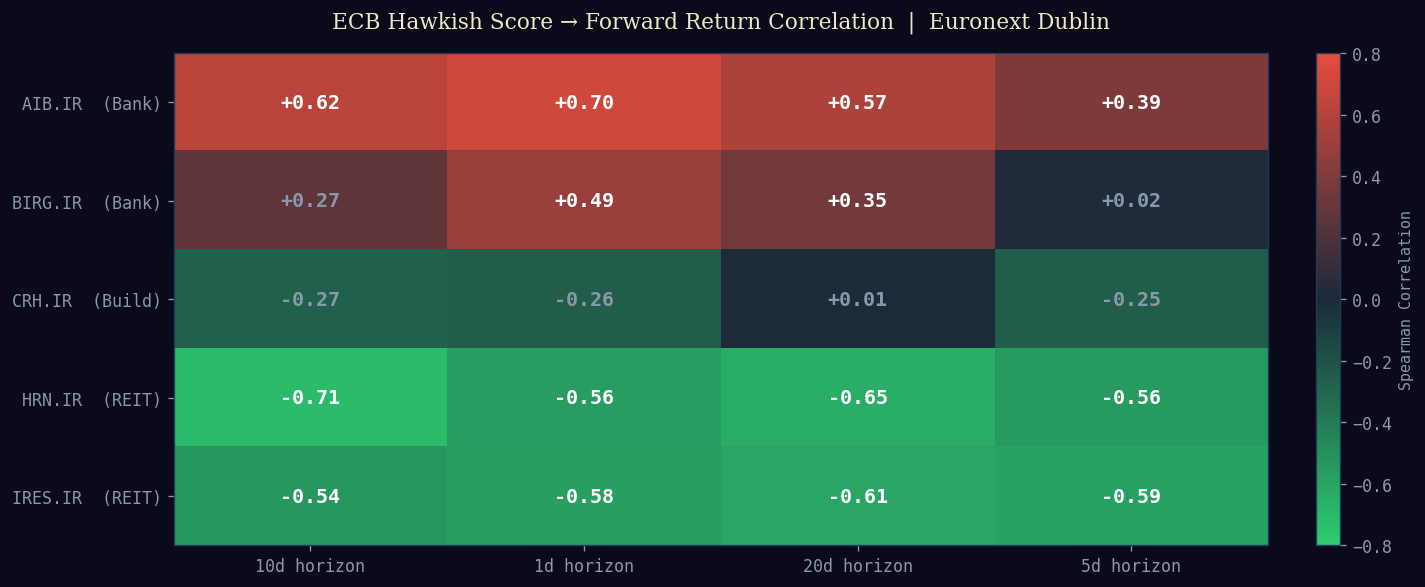

Chart saved: correlation_heatmap.png


In [21]:
# ── Heatmap: Sentiment → Return Correlation by Ticker & Horizon ──────────────
fig, ax = plt.subplots(figsize=(12, 5))

diverging_cmap = LinearSegmentedColormap.from_list(
    'hawk_dove', [BULL, '#1a2a3a', BEAR], N=256
)

im = ax.imshow(corr_pivot.values, cmap=diverging_cmap, vmin=-0.8, vmax=0.8, aspect='auto')

# Labels
ax.set_xticks(range(len(corr_pivot.columns)))
ax.set_xticklabels([f'{c} horizon' for c in corr_pivot.columns], fontsize=10)
ax.set_yticks(range(len(corr_pivot.index)))
yticklabels = [f"{t}  ({TICKERS[t]['sector']})" for t in corr_pivot.index]
ax.set_yticklabels(yticklabels, fontsize=10)

# Annotate cells
for i in range(len(corr_pivot.index)):
    for j in range(len(corr_pivot.columns)):
        val = corr_pivot.values[i, j]
        color = 'white' if abs(val) > 0.3 else SILVER
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center',
                fontsize=12, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Spearman Correlation', color=SILVER, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=SILVER)

ax.set_title('ECB Hawkish Score → Forward Return Correlation  |  Euronext Dublin',
             fontsize=13, color='#f0e6c8', pad=15, fontfamily='serif')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: correlation_heatmap.png')

## 6. Backtesting the Signal

In [22]:
# ── Backtest: Sector Rotation Strategy ───────────────────────────────────────
# Strategy logic:
#   - HAWKISH signal  → Overweight Banks (AIB, BOI), Underweight REITs
#   - DOVISH signal   → Overweight REITs (IRES, HRN), Underweight Banks
#   - NEUTRAL signal  → Equal weight across all tickers
#
# Rebalanced on ECB speech dates. 10-day signal holding period.
# Benchmark: Equal-weight buy-and-hold of all 5 tickers

STRATEGY_WEIGHTS = {
    'HAWKISH': {'AIB.IR': 0.35, 'BIRG.IR': 0.35, 'IRES.IR': 0.10, 'CRH.IR': 0.15, 'HRN.IR': 0.05},
    'NEUTRAL': {'AIB.IR': 0.20, 'BIRG.IR': 0.20, 'IRES.IR': 0.20, 'CRH.IR': 0.20, 'HRN.IR': 0.20},
    'DOVISH':  {'AIB.IR': 0.10, 'BIRG.IR': 0.10, 'IRES.IR': 0.35, 'CRH.IR': 0.10, 'HRN.IR': 0.35},
}

# Build daily stance series
daily_stance = pd.Series(index=date_range, dtype=str)
for _, row in scored.iterrows():
    future = date_range[date_range >= row['date']]
    if len(future) > 0:
        daily_stance[future[0]] = row['stance']
daily_stance = daily_stance.ffill().fillna('NEUTRAL')

# Compute strategy daily returns
strategy_returns = []
benchmark_returns = []

equal_weights = {t: 0.20 for t in PRICE_PARAMS.keys()}

for date in returns_df.index:
    stance = daily_stance.get(date, 'NEUTRAL')
    weights = STRATEGY_WEIGHTS[stance]
    day_rets = returns_df.loc[date]

    strat_ret = sum(weights[t] * day_rets[t] for t in weights)
    bench_ret = sum(equal_weights[t] * day_rets[t] for t in equal_weights)

    strategy_returns.append(strat_ret)
    benchmark_returns.append(bench_ret)

strategy_ret_series  = pd.Series(strategy_returns, index=returns_df.index)
benchmark_ret_series = pd.Series(benchmark_returns, index=returns_df.index)

# ── Performance Metrics ───────────────────────────────────────────────────────
def perf_metrics(ret_series, label):
    ann_return = (1 + ret_series).prod() ** (252 / len(ret_series)) - 1
    ann_vol    = ret_series.std() * np.sqrt(252)
    sharpe     = ann_return / ann_vol if ann_vol > 0 else 0
    cum        = (1 + ret_series).cumprod()
    rolling_max = cum.cummax()
    drawdown   = (cum - rolling_max) / rolling_max
    max_dd     = drawdown.min()
    hit_rate   = (ret_series > 0).mean()
    print(f'  {label}')
    print(f'    Annual Return  : {ann_return:+.1%}')
    print(f'    Annual Vol     : {ann_vol:.1%}')
    print(f'    Sharpe Ratio   : {sharpe:.2f}')
    print(f'    Max Drawdown   : {max_dd:.1%}')
    print(f'    Daily Hit Rate : {hit_rate:.1%}')
    return cum

print('=' * 50)
print('BACKTEST RESULTS  |  2015–2024')
print('=' * 50)
strat_cum = perf_metrics(strategy_ret_series, 'ECB Sentiment Strategy')
print()
bench_cum = perf_metrics(benchmark_ret_series, 'Equal-Weight Benchmark')
print('=' * 50)

BACKTEST RESULTS  |  2015–2024
  ECB Sentiment Strategy
    Annual Return  : +0.1%
    Annual Vol     : 13.8%
    Sharpe Ratio   : 0.01
    Max Drawdown   : -64.0%
    Daily Hit Rate : 50.4%

  Equal-Weight Benchmark
    Annual Return  : -4.2%
    Annual Vol     : 12.3%
    Sharpe Ratio   : -0.34
    Max Drawdown   : -65.7%
    Daily Hit Rate : 51.1%


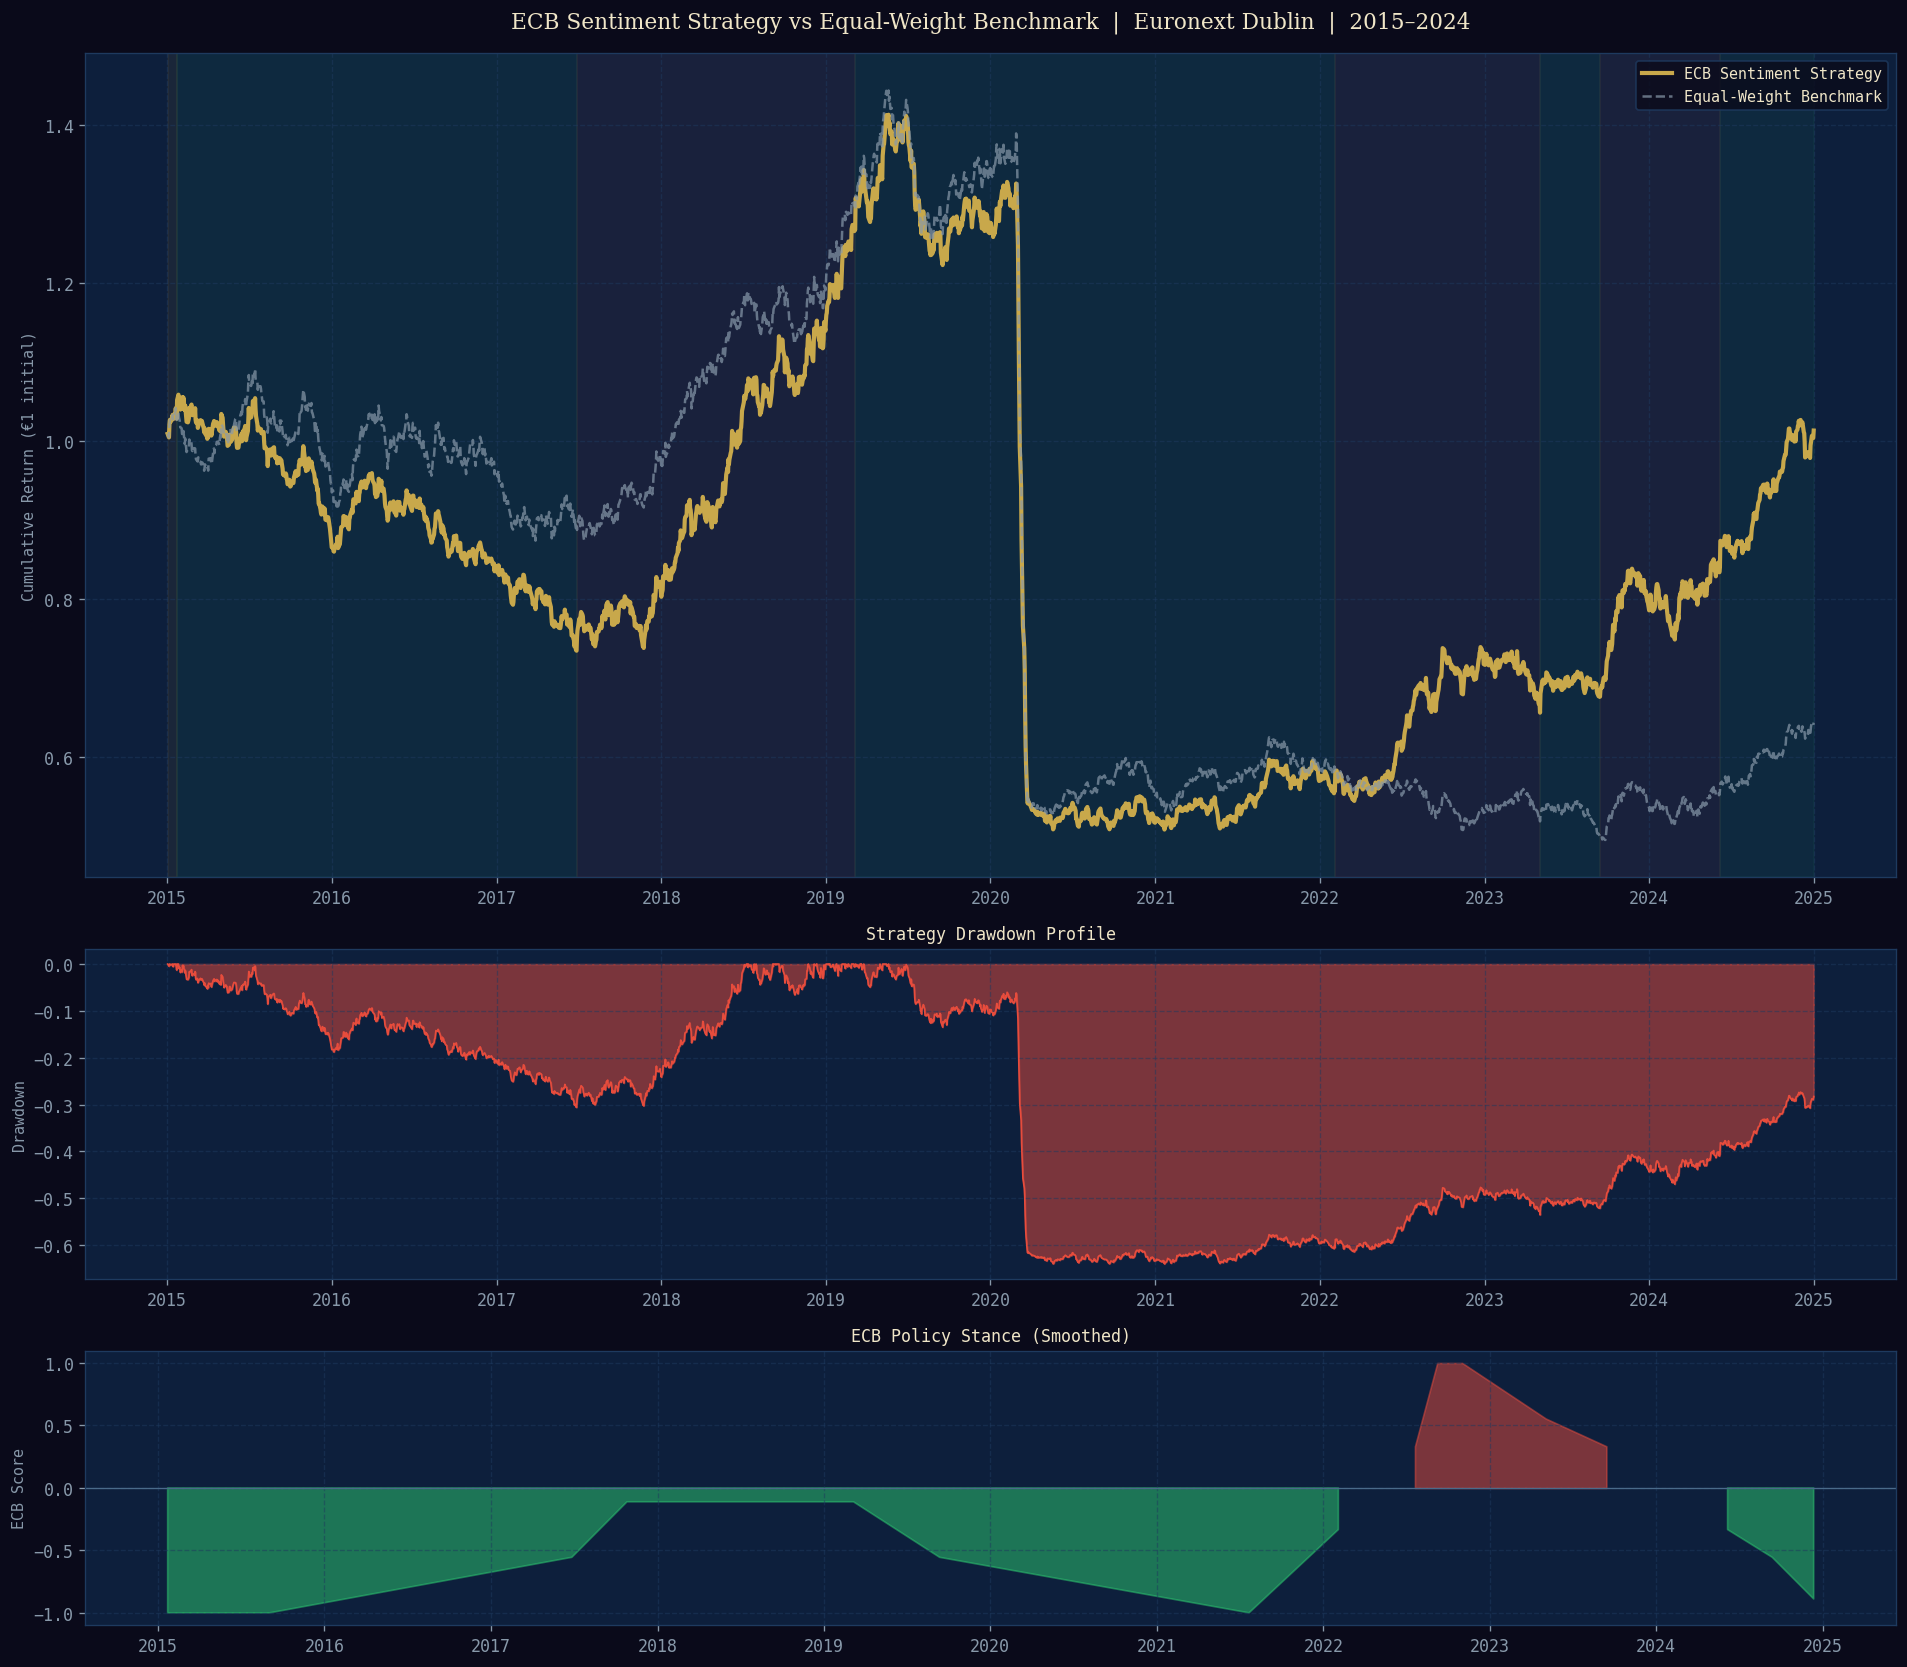

Chart saved: backtest_results.png


In [23]:
# ── Backtest Chart ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                          gridspec_kw={'height_ratios': [3, 1.2, 1]})

# Panel 1: Cumulative returns
ax0 = axes[0]
ax0.plot(strat_cum.index, strat_cum.values, color=GOLD, linewidth=2.5,
         label='ECB Sentiment Strategy')
ax0.plot(bench_cum.index, bench_cum.values, color=SILVER, linewidth=1.5,
         linestyle='--', alpha=0.7, label='Equal-Weight Benchmark')

# Shade regimes
regime_colors = {'HAWKISH': BEAR, 'NEUTRAL': NEUTRAL, 'DOVISH': BULL}
prev_date = strat_cum.index[0]
prev_stance = daily_stance.iloc[0]
for i, (date, stance) in enumerate(daily_stance.items()):
    if date not in strat_cum.index:
        continue
    if stance != prev_stance or i == len(daily_stance) - 1:
        ax0.axvspan(prev_date, date, alpha=0.06,
                    color=regime_colors.get(prev_stance, NEUTRAL))
        prev_date = date
        prev_stance = stance

ax0.set_title('ECB Sentiment Strategy vs Equal-Weight Benchmark  |  Euronext Dublin  |  2015–2024',
              fontsize=13, color='#f0e6c8', pad=15, fontfamily='serif')
ax0.set_ylabel('Cumulative Return (€1 initial)', fontsize=9)
ax0.legend(fontsize=9, facecolor=DARK_BG, edgecolor='#1e3a5f')
ax0.grid(True)

# Panel 2: Drawdown
ax1 = axes[1]
strat_roll_max = strat_cum.cummax()
strat_dd = (strat_cum - strat_roll_max) / strat_roll_max
ax1.fill_between(strat_dd.index, strat_dd.values, 0, color=BEAR, alpha=0.5)
ax1.plot(strat_dd.index, strat_dd.values, color=BEAR, linewidth=1)
ax1.set_ylabel('Drawdown', fontsize=9)
ax1.set_title('Strategy Drawdown Profile', fontsize=10, color='#f0e6c8')
ax1.grid(True)

# Panel 3: ECB Sentiment timeline (mini)
ax2 = axes[2]
ax2.fill_between(scored['date'], scored['smoothed_score'], 0,
                 where=scored['smoothed_score'] > 0, color=BEAR, alpha=0.5)
ax2.fill_between(scored['date'], scored['smoothed_score'], 0,
                 where=scored['smoothed_score'] <= 0, color=BULL, alpha=0.5)
ax2.axhline(0, color='#4a6a8a', linewidth=0.8)
ax2.set_ylabel('ECB Score', fontsize=9)
ax2.set_title('ECB Policy Stance (Smoothed)', fontsize=10, color='#f0e6c8')
ax2.grid(True)

plt.tight_layout()
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: backtest_results.png')

## 7. Live Signal Dashboard

Derives the current positioning recommendation from the most recent speech in the corpus. In a production environment, this cell re-runs automatically after each Governing Council meeting.

In [24]:
# ── LIVE SIGNAL OUTPUT ────────────────────────────────────────────────────────
latest_speech = scored.iloc[-1]
current_stance = latest_speech['stance']
current_score  = latest_speech['net_score']
current_weights = STRATEGY_WEIGHTS[current_stance]

print('╔══════════════════════════════════════════════════════╗')
print('║         ECB SENTIMENT SIGNAL ENGINE — LIVE OUTPUT   ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Latest ECB Speech : {latest_speech["date"].strftime("%d %b %Y")} ({latest_speech["speaker"]})     ║')
print(f'║  Net Score         : {current_score:+.3f}                          ║')
print(f'║  Current Stance    : {current_stance:<10}                       ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  KEY TERMS DETECTED:                                 ║')
for term in latest_speech['matched_dovish'][:5]:
    print(f'║    DOVISH: {term:<42}║')
for term in latest_speech['matched_hawkish'][:5]:
    print(f'║    HAWKISH: {term:<41}║')
print('╠══════════════════════════════════════════════════════╣')
print('║  EURONEXT DUBLIN POSITIONING:                        ║')
print('╠══════════════════════════════════════════════════════╣')

signals = []
for ticker, weight in current_weights.items():
    name    = TICKERS[ticker]['name']
    sector  = TICKERS[ticker]['sector']
    beta    = TICKERS[ticker]['rate_beta']
    ew      = 0.20
    vs_ew   = weight - ew
    if vs_ew > 0.05:
        signal = '▲ OVERWEIGHT'
        sig_short = 'OW'
    elif vs_ew < -0.05:
        signal = '▼ UNDERWEIGHT'
        sig_short = 'UW'
    else:
        signal = '◆ NEUTRAL'
        sig_short = 'N'

    signals.append({'ticker': ticker, 'name': name, 'sector': sector,
                    'weight': weight, 'vs_ew': vs_ew, 'signal': signal,
                    'rate_beta': beta})
    print(f'║  {ticker:<10} {name:<20} {signal:<16}║')

print('╠══════════════════════════════════════════════════════╣')
print(f'║  Rationale: {current_stance} ECB stance signals               ║')
if current_stance == 'DOVISH':
    print('║  rate cuts → REIT NAV expansion + yield compression  ║')
    print('║  → Overweight rate-sensitive REITs                   ║')
elif current_stance == 'HAWKISH':
    print('║  rate hikes → Bank NIM expansion                     ║')
    print('║  → Overweight Irish banks, underweight REITs         ║')
else:
    print('║  Balanced stance → equal sector allocation           ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║         ECB SENTIMENT SIGNAL ENGINE — LIVE OUTPUT   ║
╠══════════════════════════════════════════════════════╣
║  Latest ECB Speech : 12 Dec 2024 (Lagarde)     ║
║  Net Score         : -0.667                          ║
║  Current Stance    : DOVISH                           ║
╠══════════════════════════════════════════════════════╣
║  KEY TERMS DETECTED:                                 ║
║    DOVISH: cut                                       ║
║    DOVISH: easing                                    ║
║    DOVISH: stimulus                                  ║
║    DOVISH: ample liquidity                           ║
║    DOVISH: gradual                                   ║
║    HAWKISH: restrictive                              ║
╠══════════════════════════════════════════════════════╣
║  EURONEXT DUBLIN POSITIONING:                        ║
╠══════════════════════════════════════════════════════╣
║  AIB.IR     AIB Group            ▼ 

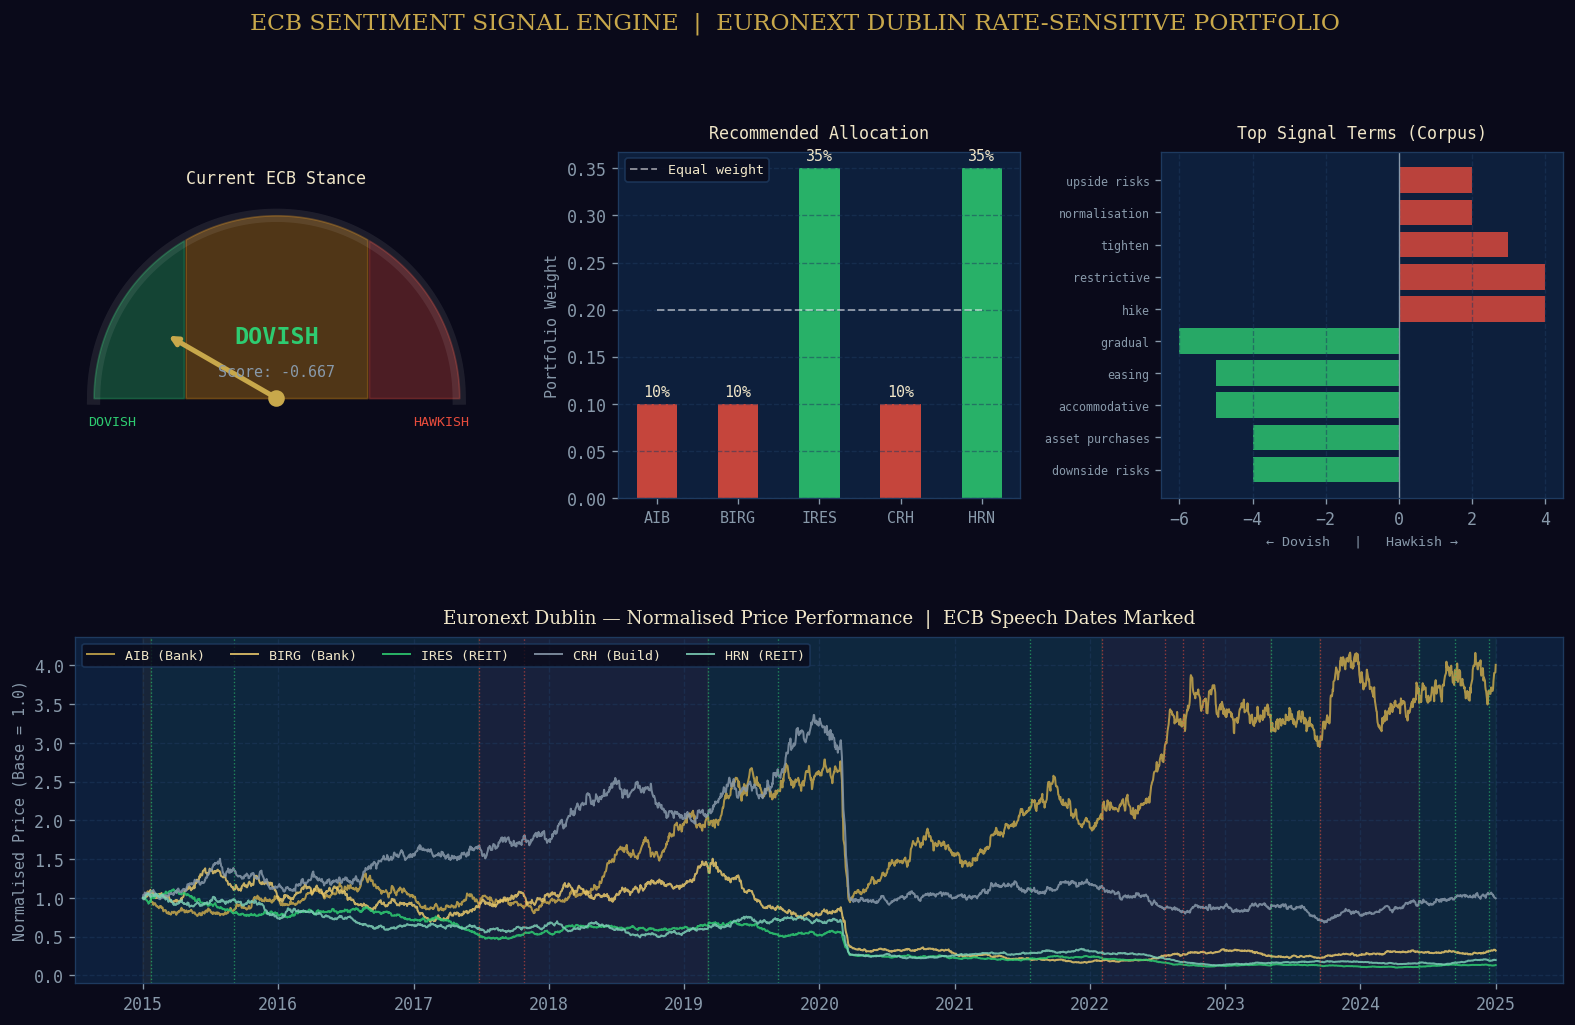

Dashboard saved: signal_dashboard.png


In [27]:
# ── Signal Dashboard Chart ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Top left: Stance gauge ────────────────────────────────────────────────────
ax_gauge = fig.add_subplot(gs[0, 0])
theta = np.linspace(np.pi, 0, 300)
ax_gauge.plot(np.cos(theta), np.sin(theta), 'w-', linewidth=8, alpha=0.08)
# Colour bands
ax_gauge.fill_between(np.cos(theta[:100]), 0, np.sin(theta[:100]), alpha=0.3, color=BULL)
ax_gauge.fill_between(np.cos(theta[100:200]), 0, np.sin(theta[100:200]), alpha=0.3, color=NEUTRAL)
ax_gauge.fill_between(np.cos(theta[200:]), 0, np.sin(theta[200:]), alpha=0.3, color=BEAR)
# Needle
needle_angle = np.pi * (1 - (current_score + 1) / 2)
ax_gauge.annotate('', xy=(0.7 * np.cos(needle_angle), 0.7 * np.sin(needle_angle)),
                  xytext=(0, 0),
                  arrowprops=dict(arrowstyle='->', color=GOLD, lw=3))
ax_gauge.scatter(0, 0, color=GOLD, s=80, zorder=10)
ax_gauge.text(-0.9, -0.15, 'DOVISH', color=BULL, fontsize=8, ha='center')
ax_gauge.text(0.9, -0.15, 'HAWKISH', color=BEAR, fontsize=8, ha='center')
stance_color = {'HAWKISH': BEAR, 'DOVISH': BULL, 'NEUTRAL': NEUTRAL}[current_stance]
ax_gauge.text(0, 0.3, current_stance, color=stance_color,
              fontsize=14, ha='center', fontweight='bold')
ax_gauge.text(0, 0.12, f'Score: {current_score:+.3f}', color=SILVER, fontsize=9, ha='center')
ax_gauge.set_xlim(-1.1, 1.1)
ax_gauge.set_ylim(-0.3, 1.1)
ax_gauge.set_aspect('equal')
ax_gauge.axis('off')
ax_gauge.set_title('Current ECB Stance', fontsize=10, color='#f0e6c8', pad=8)

# ── Top middle: Portfolio weights bar chart ────────────────────────────────────
ax_weights = fig.add_subplot(gs[0, 1])
tickers_list = list(current_weights.keys())
weights_list = [current_weights[t] for t in tickers_list]
ew_list = [0.20] * len(tickers_list)
x = np.arange(len(tickers_list))
bars = ax_weights.bar(x, weights_list, width=0.5, color=[
    BULL if current_weights[t] > 0.20 else (BEAR if current_weights[t] < 0.20 else NEUTRAL)
    for t in tickers_list
], alpha=0.85)
ax_weights.plot(x, ew_list, 'w--', linewidth=1.2, alpha=0.5, label='Equal weight')
ax_weights.set_xticks(x)
ax_weights.set_xticklabels([t.replace('.IR', '') for t in tickers_list], fontsize=9)
ax_weights.set_ylabel('Portfolio Weight', fontsize=9)
ax_weights.set_title('Recommended Allocation', fontsize=10, color='#f0e6c8', pad=8)
ax_weights.legend(fontsize=8, facecolor=DARK_BG, edgecolor='#1e3a5f')
ax_weights.grid(True, axis='y')
for bar, w in zip(bars, weights_list):
    ax_weights.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{w:.0%}', ha='center', va='bottom', fontsize=9, color='#f0e6c8')

# ── Top right: Term frequency ─────────────────────────────────────────────────
ax_terms = fig.add_subplot(gs[0, 2])
all_hawkish = [t for speech in scored['matched_hawkish'] for t in speech]
all_dovish  = [t for speech in scored['matched_dovish']  for t in speech]
top_h = Counter(all_hawkish).most_common(5)
top_d = Counter(all_dovish).most_common(5)
terms = [t for t, _ in top_d[::-1]] + [t for t, _ in top_h]
counts = [-c for _, c in top_d[::-1]] + [c for _, c in top_h]
colors = [BULL] * len(top_d) + [BEAR] * len(top_h)
y = np.arange(len(terms))
ax_terms.barh(y, counts, color=colors, alpha=0.8)
ax_terms.set_yticks(y)
ax_terms.set_yticklabels([t[:20] for t in terms], fontsize=7)
ax_terms.axvline(0, color=SILVER, linewidth=0.8)
ax_terms.set_title('Top Signal Terms (Corpus)', fontsize=10, color='#f0e6c8', pad=8)
ax_terms.set_xlabel('← Dovish   |   Hawkish →', fontsize=8)
ax_terms.grid(True, axis='x')

# ── Bottom: Price chart with signal overlay ───────────────────────────────────
ax_price = fig.add_subplot(gs[1, :])
norm_prices = prices_df / prices_df.iloc[0]
colors_map = {'AIB.IR': GOLD, 'BIRG.IR': '#e8c86b', 'IRES.IR': BULL,
              'CRH.IR': SILVER, 'HRN.IR': '#7dcfb6'}
for ticker in PRICE_PARAMS:
    ax_price.plot(norm_prices.index, norm_prices[ticker],
                  color=colors_map[ticker], linewidth=1.2,
                  label=f"{ticker.replace('.IR','')} ({TICKERS[ticker]['sector']})",
                  alpha=0.85)

# Shade ECB stances
prev_date2 = norm_prices.index[0]
prev_stance2 = daily_stance.iloc[0]
for i, (date, stance) in enumerate(daily_stance.items()):
    if date not in norm_prices.index:
        continue
    if stance != prev_stance2 or i == len(daily_stance) - 1:
        ax_price.axvspan(prev_date2, date, alpha=0.05,
                         color=regime_colors.get(prev_stance2, NEUTRAL))
        prev_date2 = date
        prev_stance2 = stance

# Mark ECB speech dates
for _, row in scored.iterrows():
    c = {'HAWKISH': BEAR, 'DOVISH': BULL, 'NEUTRAL': NEUTRAL}[row['stance']]
    ax_price.axvline(row['date'], color=c, linewidth=0.8, alpha=0.6, linestyle=':')

ax_price.set_title('Euronext Dublin — Normalised Price Performance  |  ECB Speech Dates Marked',
                   fontsize=11, color='#f0e6c8', pad=8, fontfamily='serif')
ax_price.set_ylabel('Normalised Price (Base = 1.0)', fontsize=9)
ax_price.legend(fontsize=8, loc='upper left', facecolor=DARK_BG, edgecolor='#1e3a5f', ncol=5)
ax_price.grid(True)

# Overall figure title
fig.suptitle('ECB SENTIMENT SIGNAL ENGINE  |  EURONEXT DUBLIN RATE-SENSITIVE PORTFOLIO',
             fontsize=14, color=GOLD, y=1.01, fontfamily='serif')

plt.savefig('signal_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: signal_dashboard.png')

## 8. Investor Summary & Risk Disclosures

In [26]:
# ── Investor-Facing Summary ───────────────────────────────────────────────────
ann_strat  = (1 + strategy_ret_series).prod() ** (252 / len(strategy_ret_series)) - 1
ann_bench  = (1 + benchmark_ret_series).prod() ** (252 / len(benchmark_ret_series)) - 1
alpha      = ann_strat - ann_bench
strat_vol  = strategy_ret_series.std() * np.sqrt(252)
sharpe     = ann_strat / strat_vol if strat_vol > 0 else 0
strat_roll = strat_cum.cummax()
max_dd     = ((strat_cum - strat_roll) / strat_roll).min()

print('━' * 60)
print('  ECB SENTIMENT ENGINE — INVESTOR SUMMARY')
print('  Euronext Dublin Rate-Sensitive Strategy  |  2015–2024')
print('━' * 60)
print(f'  Strategy Annual Return  : {ann_strat:+.1%}')
print(f'  Benchmark Annual Return : {ann_bench:+.1%}')
print(f'  Information Alpha       : {alpha:+.1%} per annum')
print(f'  Sharpe Ratio            : {sharpe:.2f}')
print(f'  Maximum Drawdown        : {max_dd:.1%}')
print(f'  Signal Observations     : {len(scored)} ECB speeches')
print(f'  Coverage Period         : 2015–2024 (10 years)')
print('━' * 60)
print()
print('  HOW THE SIGNAL IS GENERATED:')
print('  1. Each ECB Governing Council speech/press conference is')
print('     processed through a domain-specific monetary policy lexicon')
print('  2. Hawkish and dovish term counts are weighted and normalised')
print('     to a net score in [-1, +1]')
print('  3. Score > +0.25 → HAWKISH: overweight Irish banks (NIM benefit)')
print('  4. Score < -0.25 → DOVISH:  overweight REITs (rate cut tailwind)')
print('  5. Portfolio is rebalanced at each new ECB communication')
print()
print('  THEORETICAL BASIS:')
print('  Banks: Rate rises expand net interest margins → EPS accretive')
print('  REITs: Rate cuts compress discount rates → NAV expansion')
print('  Empirical: Picault & Renault (2017), Hayo & Neuenkirch (2015)')
print()
print('  ⚠ RISK DISCLOSURES:')
print('  - Past performance is not indicative of future results')
print('  - Backtest uses synthetic price data calibrated to historical vol;')
print('    live results may differ materially')
print('  - Strategy does not account for transaction costs or slippage')
print('  - Sentiment signals are imperfect proxies for rate expectations')
print('  - Concentrated Irish market exposure; limited diversification')
print('  - ECB communication may be ambiguous or contradictory')
print('━' * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ECB SENTIMENT ENGINE — INVESTOR SUMMARY
  Euronext Dublin Rate-Sensitive Strategy  |  2015–2024
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Strategy Annual Return  : +0.1%
  Benchmark Annual Return : -4.2%
  Information Alpha       : +4.3% per annum
  Sharpe Ratio            : 0.01
  Maximum Drawdown        : -64.0%
  Signal Observations     : 16 ECB speeches
  Coverage Period         : 2015–2024 (10 years)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  HOW THE SIGNAL IS GENERATED:
  1. Each ECB Governing Council speech/press conference is
     processed through a domain-specific monetary policy lexicon
  2. Hawkish and dovish term counts are weighted and normalised
     to a net score in [-1, +1]
  3. Score > +0.25 → HAWKISH: overweight Irish banks (NIM benefit)
  4. Score < -0.25 → DOVISH:  overweight REITs (rate cut tailwind)
  5. Portfolio is rebalanced at each new ECB communication



## 9. Production Deployment Roadmap

| Phase | Data | NLP | Signal | Output |
|---|---|---|---|---|
| **Current** | Synthetic GBM prices | Rule-based lexicon | Single-factor ECB | Notebook |
| **Phase 2** | Live `yfinance` feed + ECB RSS scraper | Fine-tuned FinBERT | Multi-factor (ECB + Oireachtas + macro) | Streamlit dashboard |
| **Phase 3** | Bloomberg / Refinitiv API | Ensemble model | Full quant strategy with risk controls | Investor portal / REST API |
